In [2]:
import torch
import numpy as np
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import to_undirected

edge_list = [
    (1, 0), (1, 2), (1, 8), (7, 4),
    (9, 2), (7, 8), (5, 2), (3, 6),
    (7, 2), (9, 4)
]


num_nodes = 10 
G = nx.Graph()
G.add_edges_from(edge_list)

coo_graph = np.array(G.edges()).T  # shape: [2, num_edges]
num_nodes = G.number_of_nodes()


edge_idx = torch.tensor(coo_graph, dtype=torch.long)
graph_data = Data(edge_index=edge_idx, num_nodes=num_nodes)


transform = RandomLinkSplit(
    is_undirected=True,
    add_negative_train_samples=False,
    neg_sampling_ratio=0.0,
    num_val=0.25,
    num_test=0.25
)
train_data, val_data, test_data = transform(graph_data)




print("TRAIN mp:", train_data.edge_index)
print("TRAIN super:", train_data.edge_label_index)
print("VAL mp:", val_data.edge_index)
print("VAL super:", val_data.edge_label_index)
print("TEST mp:", test_data.edge_index)
print("TEST super:",test_data.edge_label_index)



TRAIN mp: tensor([[1, 2, 1, 2, 3, 8, 5, 2, 7, 6],
        [8, 5, 2, 7, 6, 1, 2, 1, 2, 3]])
TRAIN super: tensor([[1, 2, 1, 2, 3],
        [8, 5, 2, 7, 6]])
VAL mp: tensor([[1, 2, 1, 2, 3, 8, 5, 2, 7, 6],
        [8, 5, 2, 7, 6, 1, 2, 1, 2, 3]])
VAL super: tensor([[2],
        [9]])
TEST mp: tensor([[1, 2, 1, 2, 3, 2, 8, 5, 2, 7, 6, 9],
        [8, 5, 2, 7, 6, 9, 1, 2, 1, 2, 3, 2]])
TEST super: tensor([[4],
        [9]])


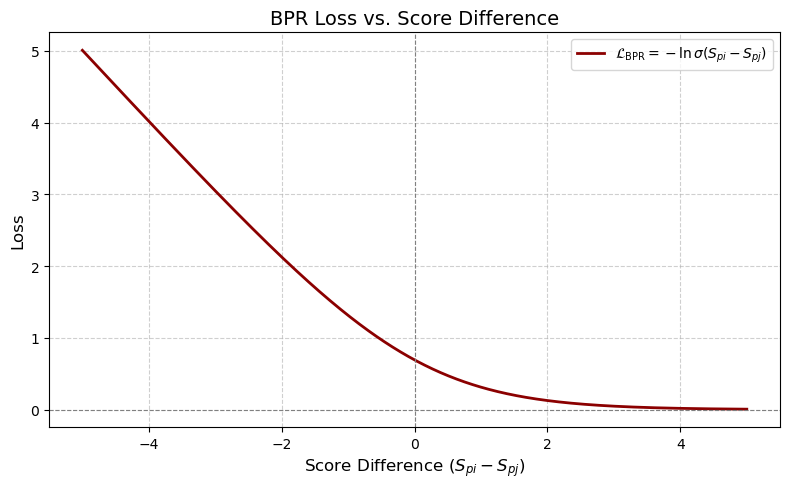

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the score difference range
x = np.linspace(-5, 5, 500)

# Compute the sigmoid function
sigmoid = 1 / (1 + np.exp(-x))

# Compute the BPR loss: negative log-sigmoid
bpr_loss = -np.log(sigmoid)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(x, bpr_loss, label=r'$\mathcal{L}_{\mathrm{BPR}} = -\ln \sigma(S_{pi} - S_{pj})$', linewidth=2, color='darkred')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("BPR Loss vs. Score Difference", fontsize=14)
plt.xlabel(r'Score Difference $(S_{pi} - S_{pj})$', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
